# Gruppo 2613
- Giacomo Bregolin 2188429
- Leonardo Fardin 2197525
- Lara Fogarolo 2199475
- Francesco Peron 2185610

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib as mpl
import tensorflow.random as tf_r
import keras_tuner
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras import Input
plt.rcParams['font.size'] = 14

np.random.seed(12345)
tf_r.set_seed(12345)

# Point 1

## Generate data

We want to study how the perfomance of the CNN, measured through accuracy, varies changing the amplitude of the pattern A while keeping DX fixed. We choose to use the same type of data generated during the lesson.

In [2]:
jump = lambda drift, stdev: int(np.random.normal(drift,stdev))

def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

Z=12

N=10000
L=60

DX = 50 
bias = 5  

In [3]:
for A in range(100,800,50):
    y = [0] * N 
    x = [[0] * L for i in range(N)] 
    
    for i in range(N):
       
        if i>0: 
            x[i][0] = x[i-1][-1] + jump(bias,DX) 
        
        for j in range(1,L):
            x[i][j] = x[i][j-1] + jump(bias,DX) 
            
        y[i] = i%3 
    
        if y[i]>0:
            j0 = np.random.randint(0,L-1-Z) 
            sign = 3-2*y[i] 
            for j in range(Z): 
                x[i][j0+j] += sign*pattern(j,Z,A) 

    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'

    fname='DATA/x_'+str0
    np.savetxt(fname,x,fmt="%d")
    fname='DATA/y_'+str0
    np.savetxt(fname,y,fmt="%d")

## CNN

We choose to use as CNN the first model used during the lesson.

In [5]:
input_shape = (L, 1)
n_class = 3 
                
reg = tf.keras.regularizers.l2(0.2)
ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05, 
                                        seed=None)
NF = 5 
model = Sequential()
model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     kernel_regularizer=reg,
                     activation='relu', 
                     input_shape=input_shape))
model.add(AveragePooling1D(5))
model.add(Conv1D(filters=5, kernel_size=7, 
                 activation='relu'))
model.add(Flatten())
model.add(Dense(12, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(n_class, activation='softmax')) # softmax !

print(model.summary())

opt = tf.keras.optimizers.Adam()

# compile the model
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           252 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            39 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 531 (2.07 KB)

 Trainable params: 531 (2.07 KB)

 Non-trainable params: 0 (0.00 B)

None


In [6]:
# TRAINING OF THE CNN OVER DIFFERENT DATASETS
BATCH_SIZE = 200
EPOCHS = 150
best_acc = 0
j = 0
models = []
acc = []

for A in range(100,800,50):
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
    fnamex='DATA/x_'+str0
    fnamey='DATA/y_'+str0
    
    x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
    
    N,L = len(x), len(x[0])

    categ = np.loadtxt(fnamey, dtype=int)  
    
    y = np.zeros((N,n_class))
    for i in range(N):
        y[i][categ[i]] = 1. # y contains one-hot encoding


    # split into training and validation sets
    perc_train=0.8
    N_train = int(perc_train*N)
    x_train = x[:N_train]
    
    y_train = y[:N_train]
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
     
    #remove average value of each sample from its values
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    # rescale with variance on the training set
    for i in range(N_train):
         x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val =  x_val.reshape(x_val.shape[0], L, 1)

    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=0, shuffle=True) 
    
    models.append(fit)    
    acc.append(fit.history['val_accuracy'][-1])
    
    if fit.history['val_accuracy'][-1] > best_acc:
        best_acc = fit.history['val_accuracy'][-1]
        best_model = fit
        best_A = A

    print(f"Training dataset: {j}")
    j+=1

Training dataset: 0
Training dataset: 1
Training dataset: 2
Training dataset: 3
Training dataset: 4
Training dataset: 5
Training dataset: 6
Training dataset: 7
Training dataset: 8
Training dataset: 9
Training dataset: 10
Training dataset: 11
Training dataset: 12
Training dataset: 13


In [7]:
print("Amplitude that determines the best performance of the CNN: ", best_A)

Amplitude that determines the best performance of the CNN:  750


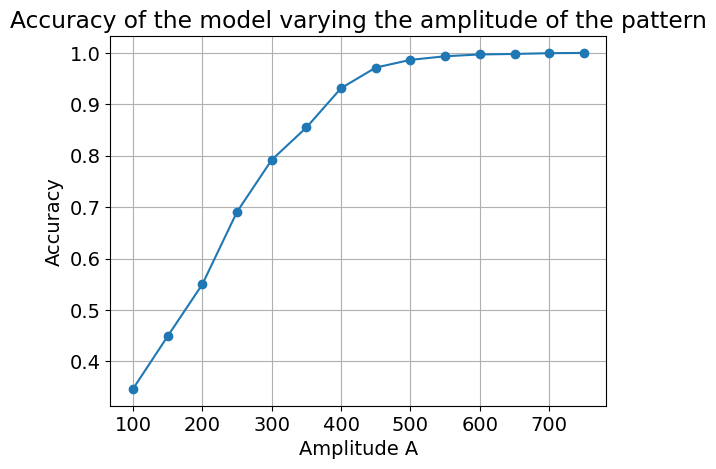

In [8]:
plt.plot(np.arange(100, 800, 50), acc, marker='o')
plt.xlabel("Amplitude A")
plt.ylabel("Accuracy")
plt.title("Accuracy of the model varying the amplitude of the pattern")
plt.grid()
plt.show()

As we expect, the accuracy of the model is better for greater values of A.

# Point 3

We created our model where we can choose them lambda and the regularizers, while also varying the learnig rate and the optimizier. Number of filters stays the same.

We then search for the best hyperparameters and show how the accuracy behaves while changing the values of the parameters.

In [10]:
str0 = 'ts_L60_Z12_A750_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding

data:  10000


In [11]:
def build_model(hp):
    np.random.seed(12345)
    tf_r.set_seed(12345)
    
    # Search over regularization type
    reg_type = hp.Choice("reg_type", values=["l1", "l2", "l1_l2", "none"])
    
    # Search over lambda strength
    lambda_val = hp.Float("lambda", min_value=1e-4, max_value=0.5, sampling="log")
    
    # Map choice to actual regularizer
    if reg_type == "l1":
        reg = tf.keras.regularizers.l1(lambda_val)
    elif reg_type == "l2":
        reg = tf.keras.regularizers.l2(lambda_val)
    elif reg_type == "l1_l2":
        reg = tf.keras.regularizers.l1_l2(l1=lambda_val, l2=lambda_val)
    elif reg_type == "none":
        reg = None

    # actual CNN
    model = Sequential()
    
    NCONV = 1
    NF = 5
    
    
    model.add(Conv1D(filters=NF, kernel_size=11,
                     kernel_initializer=ini,
                     kernel_regularizer=reg,
                     activation='relu',
                     input_shape=input_shape))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
    model.add(Flatten())
    dense_units = hp.Int("dense_units", min_value=8, max_value=32, step=4)
    model.add(Dense(dense_units, activation='relu'))
    dropout = hp.Float("dropout_1", min_value=0.0, max_value=0.5, step=0.1)
    model.add(Dropout(dropout))


    model.add(Dense(n_class, activation='softmax'))

    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])

    if optimizer_name == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "nadam":
        opt = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=opt,
                  metrics=['accuracy'])
    return model

Finding the best parameters 

In [30]:
search = True
if search:
    tuner = keras_tuner.BayesianOptimization(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=50,
        executions_per_trial=1,
        overwrite=True,
        directory="cnn_trials",
        project_name="cnn_search"
    )
    
    tuner.search(x_train, y_train,
                 epochs=50,
                 validation_data=(x_val, y_val),
                 verbose=2)

else:
    tuner = keras_tuner.BayesianOptimization(
        hypermodel=build_model,
        objective="val_accuracy",
        max_trials=50,
        executions_per_trial=1,
        overwrite=False,
        directory="cnn_trials",
        project_name="cnn_search"
    )

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(1)[0]

Trial 50 Complete [00h 00m 22s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 19m 03s


In [29]:
print("Best learning_rate:",best_hp.get("learning_rate"))
print("Best optimizer:",    best_hp.get("optimizer"))
print("Best reg_type:", best_hp.get("reg_type"))
print("Best lambda:",   best_hp.get("lambda"))

Best learning_rate: 0.0023949500544728688
Best optimizer: nadam
Best reg_type: l2
Best lambda: 0.11621798673419767


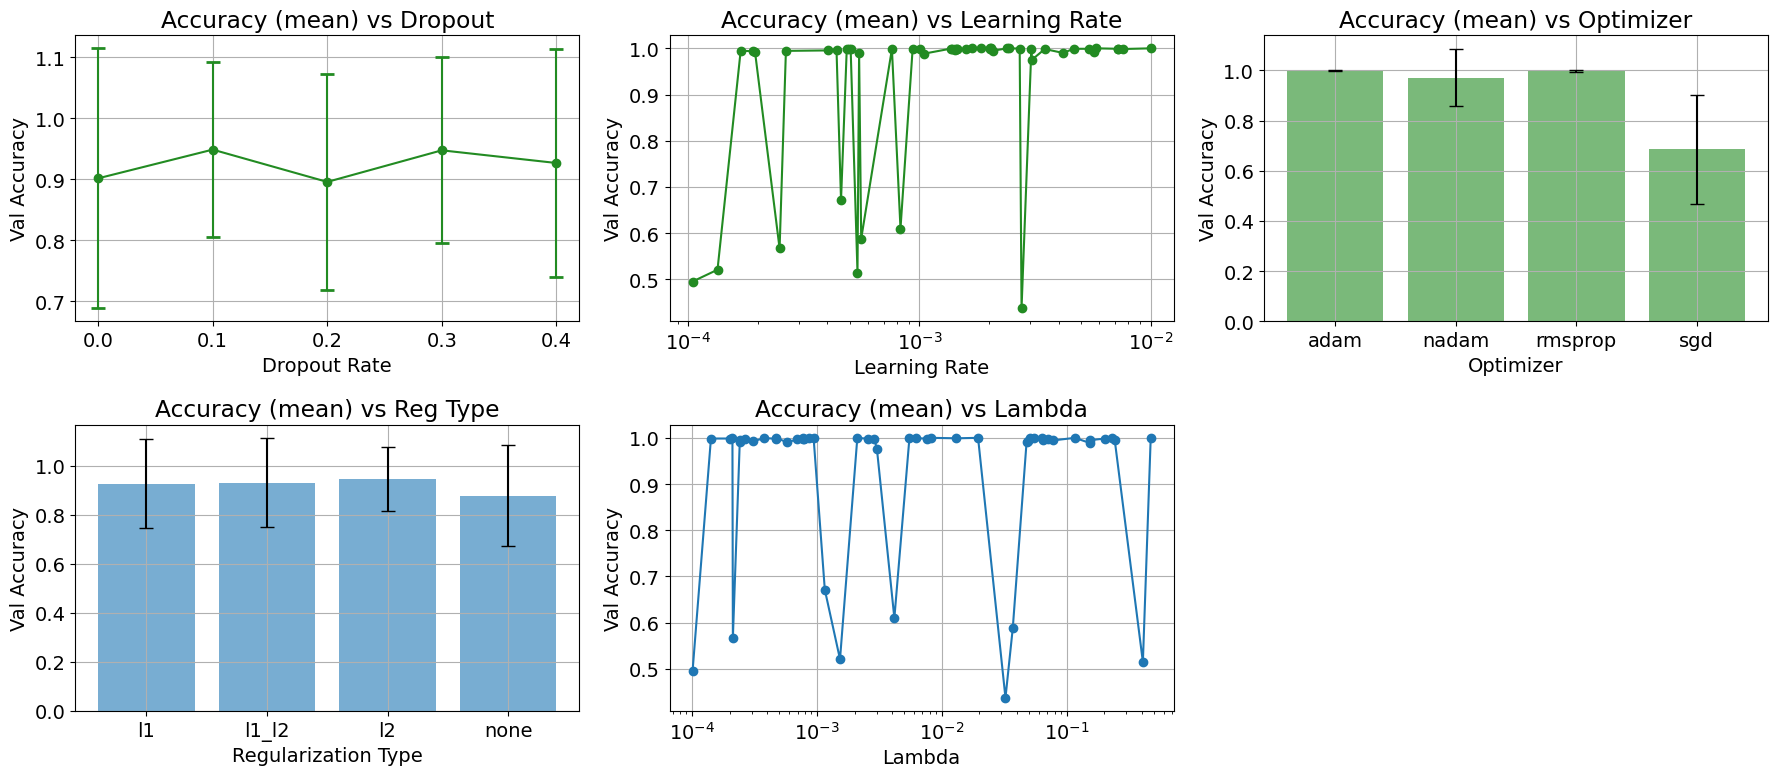

In [14]:
# First extract all results from tuner
trials = tuner.oracle.trials
results = []
for trial in trials.values():
    hp_vals = trial.hyperparameters.values
    results.append({
        "val_accuracy":  trial.score,
        "reg_type":      hp_vals.get("reg_type"),
        "lambda":        hp_vals.get("lambda"),
        "learning_rate": hp_vals.get("learning_rate"),
        "optimizer":     hp_vals.get("optimizer"),
        "dropout":       hp_vals.get("dropout_1")
    })
df = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(18,8))

# 1. Dropout
drop_mean = df.groupby("dropout")["val_accuracy"].mean()
drop_std  = df.groupby("dropout")["val_accuracy"].std()
ax[0][0].errorbar(drop_mean.index, drop_mean.values, yerr=drop_std.values, color = 'forestgreen',
                  marker='o', capsize=5, capthick=2, elinewidth=1.5)
ax[0][0].set_xlabel("Dropout Rate")
ax[0][0].set_ylabel("Val Accuracy")
ax[0][0].set_title("Accuracy (mean) vs Dropout")
ax[0][0].grid(True)

# 2. Learning rate
lear_mean = df.groupby("learning_rate")["val_accuracy"].mean()
lear_std  = df.groupby("learning_rate")["val_accuracy"].std()
ax[0][1].errorbar(lear_mean.index, lear_mean.values, yerr=lear_std.values, color = 'forestgreen',
                  marker='o', capsize=5, capthick=2, elinewidth=1.5)
ax[0][1].set_xscale("log")
ax[0][1].set_xlabel("Learning Rate")
ax[0][1].set_ylabel("Val Accuracy")
ax[0][1].set_title("Accuracy (mean) vs Learning Rate")
ax[0][1].grid(True)

# 3. Optimizer
opti_mean = df.groupby("optimizer")["val_accuracy"].mean()
opti_std  = df.groupby("optimizer")["val_accuracy"].std()
ax[0][2].bar(opti_mean.index, opti_mean.values, yerr=opti_std.values, color = 'forestgreen', alpha = 0.6,
             capsize=5)
ax[0][2].set_xlabel("Optimizer")
ax[0][2].set_ylabel("Val Accuracy")
ax[0][2].set_title("Accuracy (mean) vs Optimizer")
ax[0][2].grid(True)

# 4. Regularization type
regt_mean = df.groupby("reg_type")["val_accuracy"].mean()
regt_std  = df.groupby("reg_type")["val_accuracy"].std()
ax[1][0].bar(regt_mean.index, regt_mean.values, yerr=regt_std.values, alpha = 0.6,
             capsize=5)
ax[1][0].set_xlabel("Regularization Type")
ax[1][0].set_ylabel("Val Accuracy")
ax[1][0].set_title("Accuracy (mean) vs Reg Type")
ax[1][0].grid(True)

# 5. Lambda
lamb_mean = df.groupby("lambda")["val_accuracy"].mean()
lamb_std  = df.groupby("lambda")["val_accuracy"].std()
ax[1][1].errorbar(lamb_mean.index, lamb_mean.values, yerr=lamb_std.values,
                  marker='o', capsize=5, capthick=2, elinewidth=1.5)
ax[1][1].set_xscale("log")
ax[1][1].set_xlabel("Lambda")
ax[1][1].set_ylabel("Val Accuracy")
ax[1][1].set_title("Accuracy (mean) vs Lambda")
ax[1][1].grid(True)

# 6.
ax[1][2].axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Get the top 2 models.
models = tuner.get_best_models(num_models=1)
best_model = models[0]
best_model.summary()

/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 19 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 5)          │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 10, 5)          │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 5)           │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 627 (2.45 KB)

 Trainable params: 627 (2.45 KB)

 Non-trainable params: 0 (0.00 B)

(11, 1, 5)
(5, 1, 11)


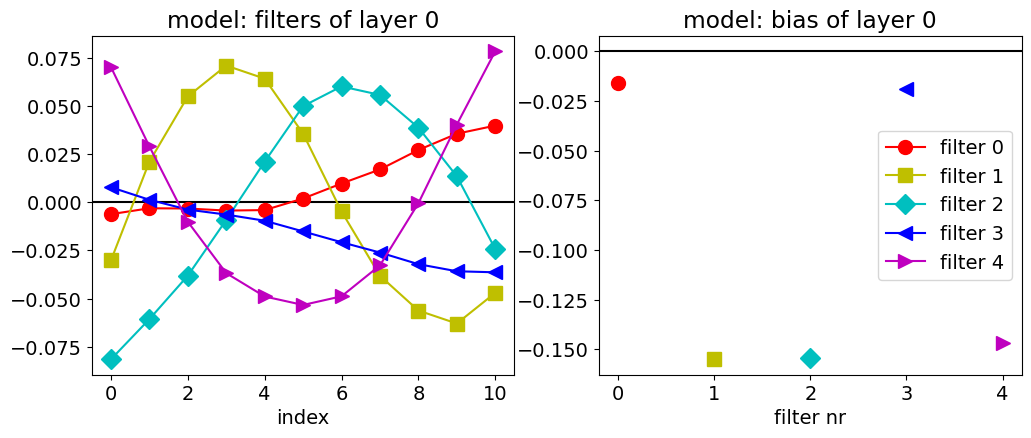

(7, 5, 5)
(5, 5, 7)


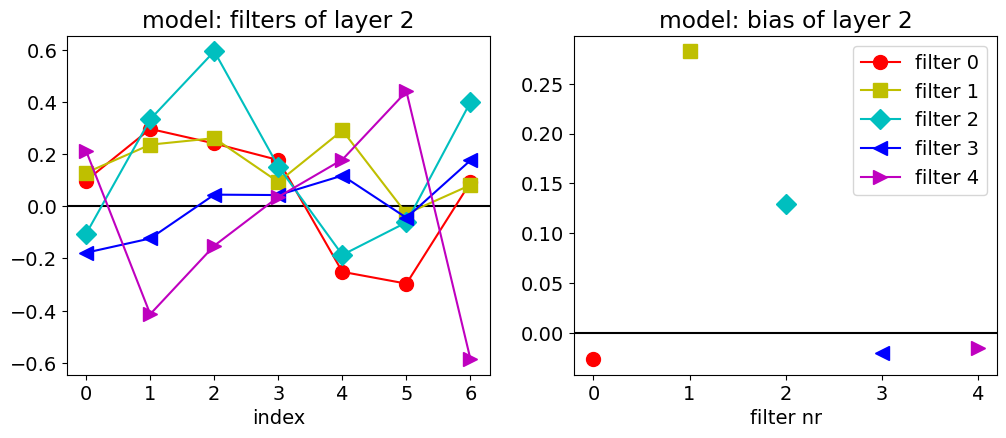

In [17]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
Show_weights(best_model,0)
Show_weights(best_model,2)

In [18]:
BATCH_SIZE = 200
EPOCHS = 150

fit = best_model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 

Epoch 1/150
40/40 - 1s - 21ms/step - accuracy: 0.9995 - loss: 0.0098 - val_accuracy: 0.9980 - val_loss: 0.0118
Epoch 2/150
40/40 - 0s - 3ms/step - accuracy: 0.9994 - loss: 0.0090 - val_accuracy: 0.9980 - val_loss: 0.0112
Epoch 3/150
40/40 - 0s - 3ms/step - accuracy: 0.9992 - loss: 0.0095 - val_accuracy: 0.9980 - val_loss: 0.0139
Epoch 4/150
40/40 - 0s - 2ms/step - accuracy: 0.9996 - loss: 0.0079 - val_accuracy: 0.9990 - val_loss: 0.0089
Epoch 5/150
40/40 - 0s - 3ms/step - accuracy: 0.9998 - loss: 0.0066 - val_accuracy: 0.9990 - val_loss: 0.0085
Epoch 6/150
40/40 - 0s - 3ms/step - accuracy: 0.9998 - loss: 0.0062 - val_accuracy: 0.9990 - val_loss: 0.0089
Epoch 7/150
40/40 - 0s - 3ms/step - accuracy: 0.9999 - loss: 0.0060 - val_accuracy: 0.9985 - val_loss: 0.0090
Epoch 8/150
40/40 - 0s - 3ms/step - accuracy: 1.0000 - loss: 0.0057 - val_accuracy: 0.9985 - val_loss: 0.0085
Epoch 9/150
40/40 - 0s - 3ms/step - accuracy: 0.9996 - loss: 0.0060 - val_accuracy: 0.9975 - val_loss: 0.0112
Epoch 10/

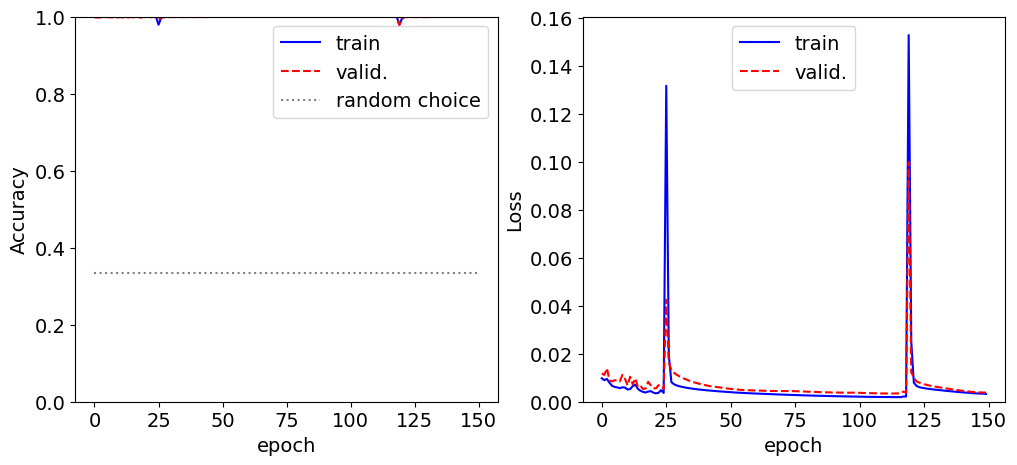

(11, 1, 5)
(5, 1, 11)


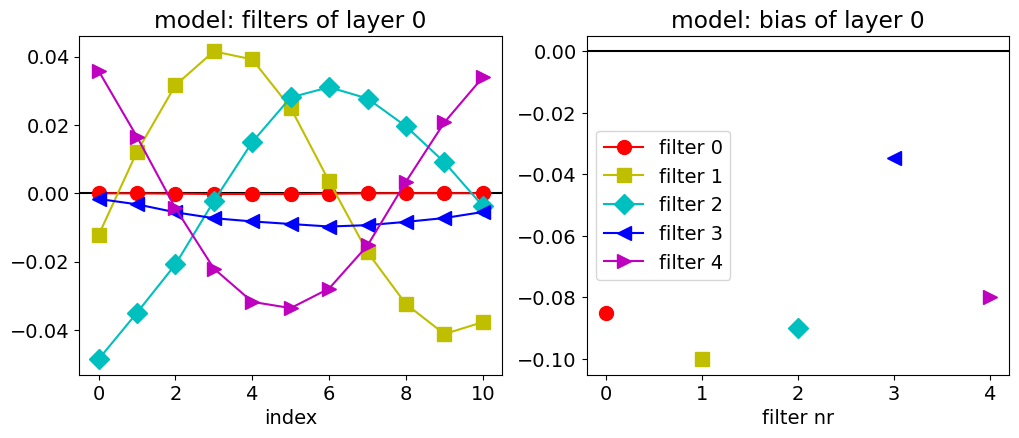

(7, 5, 5)
(5, 5, 7)


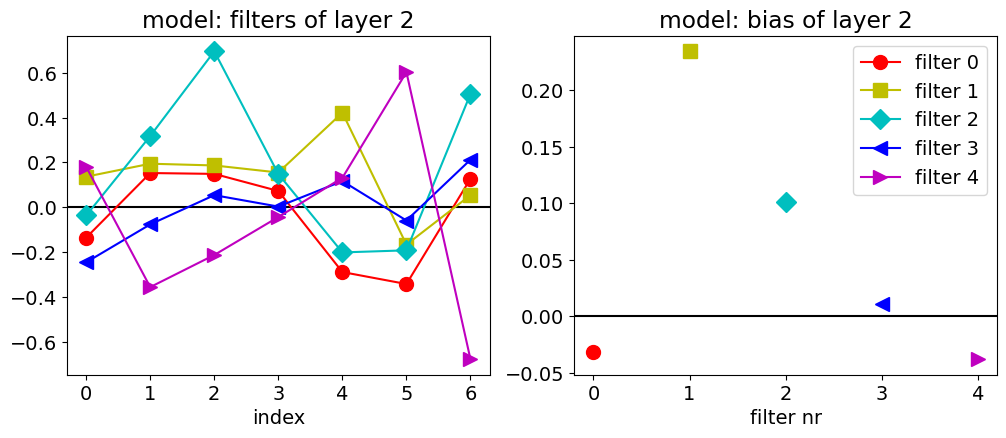

In [24]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0] 
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
Show_history(fit)

Finding the best models using L1 and L2, than plotting the weights in order to visualize differencies

In [21]:
def build_model_l1(hp):
    np.random.seed(12345)
    tf_r.set_seed(12345)
    
    # Search over regularization type
    reg_type = "l1"
    
    # Search over lambda strength
    lambda_val = hp.Float("lambda", min_value=1e-4, max_value=0.5, sampling="log")
    
    # Map choice to actual regularizer
    if reg_type == "l1":
        reg = tf.keras.regularizers.l1(lambda_val)
    elif reg_type == "l2":
        reg = tf.keras.regularizers.l2(lambda_val)
    elif reg_type == "l1_l2":
        reg = tf.keras.regularizers.l1_l2(l1=lambda_val, l2=lambda_val)
    elif reg_type == "none":
        reg = None

    # actual CNN
    model = Sequential()
    
    NCONV = 1
    NF = 5
    
    if NCONV == 1:
        model.add(Conv1D(filters=NF, kernel_size=11,
                         kernel_initializer=ini,
                         kernel_regularizer=reg,
                         activation='relu',
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
        model.add(Flatten())
        dense_units = hp.Int("dense_units_1", min_value=8, max_value=32, step=4)
        model.add(Dense(dense_units, activation='relu'))
        dropout = hp.Float("dropout_1", min_value=0.0, max_value=0.5, step=0.1)
        model.add(Dropout(dropout))


    model.add(Dense(n_class, activation='softmax'))

    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])

    if optimizer_name == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "nadam":
        opt = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=opt,
                  metrics=['accuracy'])
    return model

In [22]:
def build_model_l2(hp):
    np.random.seed(12345)
    tf_r.set_seed(12345)
    
    # Search over regularization type
    reg_type = "l2"
    
    # Search over lambda strength
    lambda_val = hp.Float("lambda", min_value=1e-4, max_value=0.5, sampling="log")
    
    # Map choice to actual regularizer
    if reg_type == "l1":
        reg = tf.keras.regularizers.l1(lambda_val)
    elif reg_type == "l2":
        reg = tf.keras.regularizers.l2(lambda_val)
    elif reg_type == "l1_l2":
        reg = tf.keras.regularizers.l1_l2(l1=lambda_val, l2=lambda_val)
    elif reg_type == "none":
        reg = None

    # actual CNN
    model = Sequential()
    
    NCONV = 1
    NF = 5
    
    if NCONV == 1:
        model.add(Conv1D(filters=NF, kernel_size=11,
                         kernel_initializer=ini,
                         kernel_regularizer=reg,
                         activation='relu',
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
        model.add(Flatten())
        dense_units = hp.Int("dense_units_1", min_value=8, max_value=32, step=4)
        model.add(Dense(dense_units, activation='relu'))
        dropout = hp.Float("dropout_1", min_value=0.0, max_value=0.5, step=0.1)
        model.add(Dropout(dropout))


    model.add(Dense(n_class, activation='softmax'))

    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    optimizer_name = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "nadam"])

    if optimizer_name == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif optimizer_name == "nadam":
        opt = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

    model.compile(loss=keras.losses.categorical_crossentropy,
                  optimizer=opt,
                  metrics=['accuracy'])
    return model

In [23]:
search = True
if search:
    tuner1 = keras_tuner.BayesianOptimization(
        hypermodel=build_model_l1,
        objective="val_accuracy",
        max_trials=50,
        executions_per_trial=1,
        overwrite=True,
        directory="cnn_trials",
        project_name="cnn_search_1"
    )
    
    tuner1.search(x_train, y_train,
                 epochs=50,
                 validation_data=(x_val, y_val),
                 verbose=2)

else:
    tuner1 = keras_tuner.BayesianOptimization(
        hypermodel=build_model_l1,
        objective="val_accuracy",
        max_trials=50,
        executions_per_trial=1,
        overwrite=False,
        directory="cnn_trials",
        project_name="cnn_search_1"
    )


if search:
    tuner2 = keras_tuner.BayesianOptimization(
        hypermodel=build_model_l2,
        objective="val_accuracy",
        max_trials=50,
        executions_per_trial=1,
        overwrite=True,
        directory="cnn_trials",
        project_name="cnn_search_2"
    )
    
    tuner2.search(x_train, y_train,
                 epochs=50,
                 validation_data=(x_val, y_val),
                 verbose=2)

else:
    tuner2 = keras_tuner.BayesianOptimization(
        hypermodel=build_model_l2,
        objective="val_accuracy",
        max_trials=50,
        executions_per_trial=1,
        overwrite=False,
        directory="cnn_trials",
        project_name="cnn_search_2"
    )

Trial 50 Complete [00h 00m 21s]
val_accuracy: 1.0

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 18m 32s


In [26]:
models_1 = tuner1.get_best_models(num_models=1)
best_model_1 = models_1[0]
models_2 = tuner2.get_best_models(num_models=1)
best_model_2 = models_2[0]

/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'nadam', because it has 2 variables whereas the saved optimizer has 19 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/lenovo/anaconda3/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


(11, 1, 5)
(5, 1, 11)


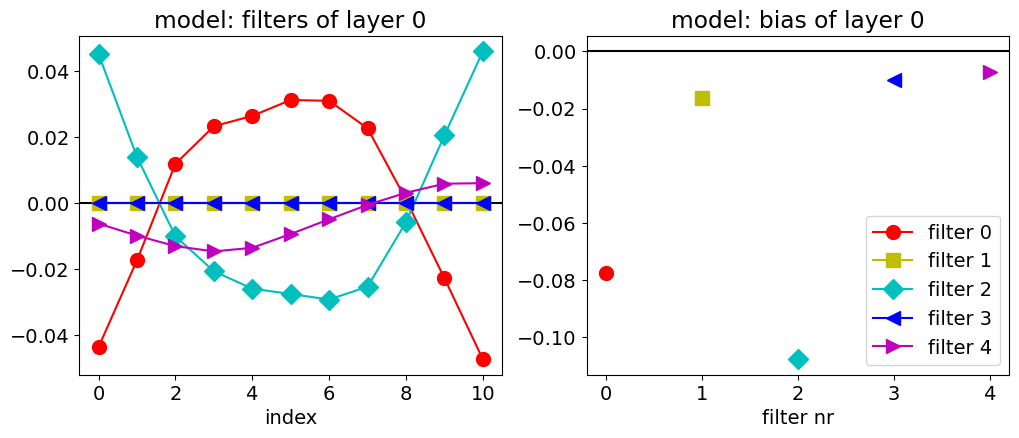

(7, 5, 5)
(5, 5, 7)


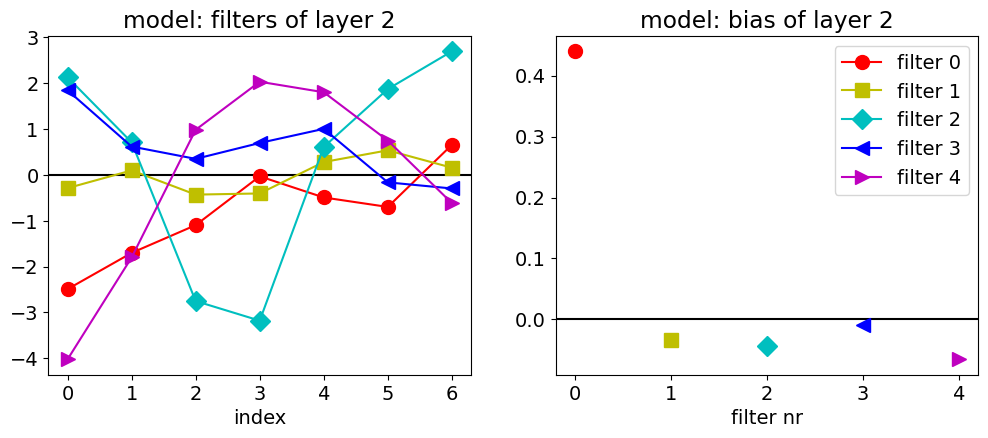

In [27]:
def Show_weights(best_model_1,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
Show_weights(best_model_1,0)
Show_weights(best_model_1,2)

(11, 1, 5)
(5, 1, 11)


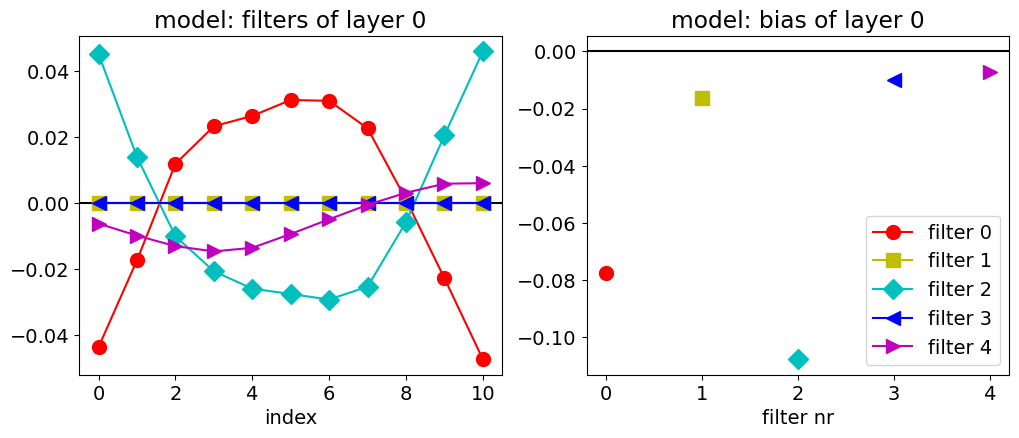

(7, 5, 5)
(5, 5, 7)


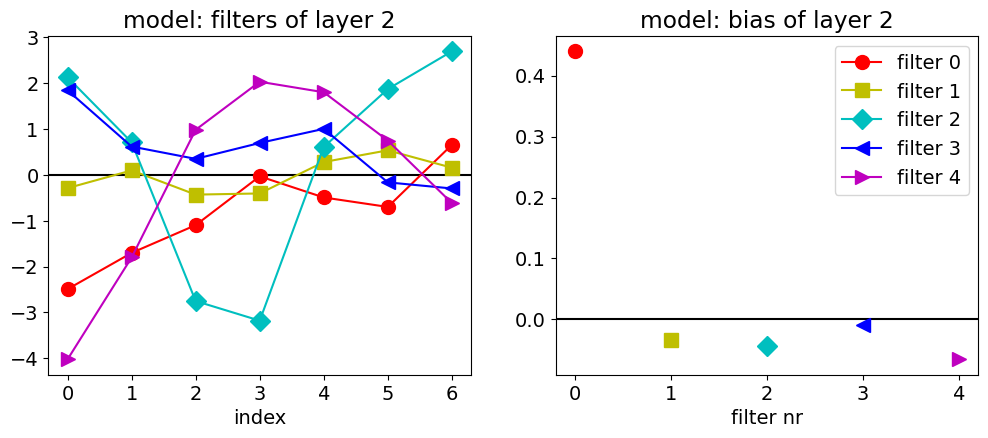

In [28]:
def Show_weights(best_model_2,l=0,label="model"):
    c=['r','y','c','b','m']
    m=['o','s','D','<','>']
    ms=10
    
    w = model.layers[l].get_weights()[0] # weights
    print(w.shape)
    wT=w.T
    print(wT.shape)
    M=len(wT)
    b = model.layers[l].get_weights()[1] # bias
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i],marker=m[i],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i],marker=m[i],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
Show_weights(best_model_2,0)
Show_weights(best_model_2,2)

The weights remain the same using L1 and L2, tath's could happen because of the smoothness of the dataset, where the amplitude $A$ is bigger than the variance of the random walk $\sigma$ = DX $\sqrt Z$, that lead to an high value of the accuracy in both cases. 